In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from cuml.tsa import ARIMA

In [5]:
# Get exemplary basin discharge and coverage stats for basins. 
data_path = Path("/home/wuhlmann/BA/data")

basin_669_q = pd.read_table(data_path / "raw_data/LamaH-CE_daily/D_gauges/2_timeseries/daily/ID_669.csv", header=0, sep=";")
coverage = pd.read_csv(
    data_path / "processed_data/eda/intermediate/discharge_coverage.csv",
    header=0,
    sep=";",
    converters={"gap_dates": pd.eval}
)

coverage.set_index("basin_id", inplace=True)

# Create date for easier indexing.
basin_669_q = basin_669_q.rename(columns={"YYYY": "year", "MM": "month", "DD": "day"})
basin_669_q["date"] = pd.to_datetime(basin_669_q[["year", "month", "day"]])
basin_669_q.set_index("date", inplace=True)

basin_669_gaps = coverage.loc[669, "gap_dates"]

train_start = coverage.loc[669,"start"]
train_end = coverage.loc[669,"gap_dates"][0][0] - pd.Timedelta(days=1)

q_train = basin_669_q.loc[train_start:train_end, "qobs"]

# Prep for cuML
#q_cuml_train = q_train.astype("float32").reset_index(drop=True)

model = ARIMA(q_train, order=(1,0,0), seasonal_order=(1,1,0,21))
result = model.fit()

<Axes: xlabel='date'>

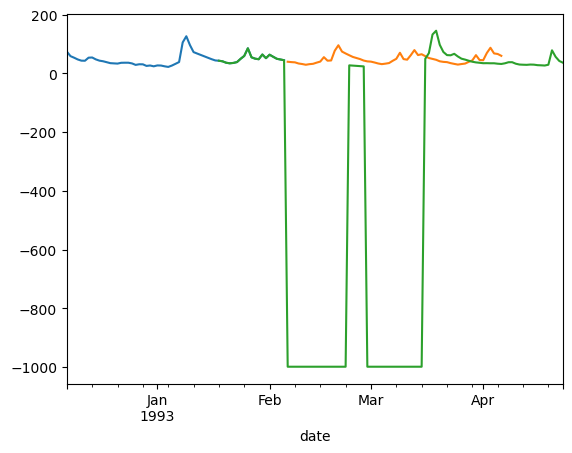

In [7]:
fc = result.forecast(60)

forecast_dates = pd.date_range(basin_669_gaps[0][0], basin_669_gaps[0][1]+ pd.Timedelta(days=43), freq="1D")

fc.index = forecast_dates


basin_669_q.loc[train_end-pd.Timedelta(days=60):train_end,"qobs"].plot()
fc.plot()
basin_669_q.loc[train_end - pd.Timedelta(days=18):train_end + pd.Timedelta(days=77),"qobs"].plot()
